In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


## модель PINN

In [3]:
class PINN(nn.Module):
    def __init__(self, hidden=64, depth=3):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        return self.net(inp)

## невязка уравнения Бюргерса

In [4]:
def burgers_residual(model, t, x, nu):
    u = model(t, x)

    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]

    return u_t + u * u_x - nu * u_xx


## многомасштабный оператор локальной осцилляции

In [5]:
def make_avg_kernel_1d(r_pix, device):
    ksize = 2 * r_pix + 1
    kernel = torch.ones(1, 1, ksize, device=device)
    kernel = kernel / kernel.sum()
    return kernel


In [6]:
def discrete_m_osc_1d(u_tensor, radii, dx, q=1, use_softmax=False, tau=0.05):
    """
    Parameters
    ----------
    u_tensor : torch.Tensor
        shape [batch, 1, n]
    radii : iterable of float
        radii in physical coordinates
    dx : float
        spatial step
    q : float
        oscillation exponent
    use_softmax : bool
        if True, use logsumexp instead of hard max
    tau : float
        smoothing temperature

    Returns
    -------
    torch.Tensor
        shape [batch, 1, n]
    """
    device = u_tensor.device
    vals = []

    for r in radii:
        r_pix = int(round(r / dx))
        if r_pix < 1:
            continue

        kernel = make_avg_kernel_1d(r_pix, device)

        # local mean
        u_pad = F.pad(u_tensor, (r_pix, r_pix), mode='replicate')
        avg = F.conv1d(u_pad, kernel)

        # local oscillation
        if q == 1:
            dev = torch.abs(u_tensor - avg)
            dev_pad = F.pad(dev, (r_pix, r_pix), mode='replicate')
            osc = F.conv1d(dev_pad, kernel)
        else:
            dev = torch.abs(u_tensor - avg) ** q
            dev_pad = F.pad(dev, (r_pix, r_pix), mode='replicate')
            osc = F.conv1d(dev_pad, kernel) ** (1.0 / q)

        vals.append(osc)

    if len(vals) == 0:
        raise ValueError("No valid radii: all radii are smaller than dx.")

    stacked = torch.stack(vals, dim=0)  # [num_radii, batch, 1, n]

    if use_softmax:
        return tau * torch.logsumexp(stacked / tau, dim=0)
    else:
        return torch.max(stacked, dim=0).values


## тест совместимости с autograd

In [7]:
def test_autograd_support_1d():
    u = torch.randn(2, 1, 128, requires_grad=True)
    radii = [0.02, 0.04, 0.08]
    dx = 2.0 / 127

    m = discrete_m_osc_1d(
        u_tensor=u,
        radii=radii,
        dx=dx,
        q=1,
        use_softmax=True,
        tau=0.05
    )
    loss = torch.mean(m ** 2)
    loss.backward()

    if u.grad is not None and not torch.isnan(u.grad).any():
        print(f"[Autograd Test] OK | grad norm = {u.grad.norm().item():.6f}")
    else:
        print("[Autograd Test] FAILED")


## альтернативные регуляризаторы

In [8]:
def grad_regularization(model, t_grid, x_grid):
    t = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)
    x = x_grid.reshape(-1, 1).clone().detach().requires_grad_(True)

    u = model(t, x)
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    return torch.mean(u_x ** 2)


In [9]:
def hessian_regularization(model, t_grid, x_grid):
    t = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)
    x = x_grid.reshape(-1, 1).clone().detach().requires_grad_(True)

    u = model(t, x)
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]
    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]

    return torch.mean(u_xx ** 2)


In [10]:
def tv_regularization(model, t_grid, x_grid, eps=1e-6):
    t = t_grid.reshape(-1, 1).clone().detach().requires_grad_(True)
    x = x_grid.reshape(-1, 1).clone().detach().requires_grad_(True)

    u = model(t, x)
    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    return torch.mean(torch.sqrt(u_x ** 2 + eps))


## эталонный конечно-разностный решатель

In [24]:
from scipy.integrate import solve_ivp

def burgers_reference_solver(
    nu,
    nx=512,
    nt=100,  # теперь это число точек сохранения, решатель сам подберет шаги dt
    x_left=-1.0,
    x_right=1.0,
    t_final=1.0
):
    """
    Устойчивый неявный решатель для эталонного решения уравнения Бюргерса.
    Использует метод Radau (жесткие системы Oде), который не взрывается от CFL.
    """
    x = np.linspace(x_left, x_right, nx)
    dx = x[1] - x[0]

    # Начальное условие
    u0 = -np.sin(np.pi * x)
    u0[0] = 0.0
    u0[-1] = 0.0

    def rhs(t, u):
        du = np.zeros_like(u)
        # Центральные разности
        ux = (u[2:] - u[:-2]) / (2.0 * dx)
        uxx = (u[2:] - 2.0 * u[1:-1] + u[:-2]) / (dx ** 2)

        du[1:-1] = -u[1:-1] * ux + nu * uxx
        return du

    # Точки, в которых мы хотим сохранить решение
    t_eval = np.linspace(0.0, t_final, nt + 1)

    # Запускаем неявный решатель 'Radau' (идеален для жестких уравнений типа Бюргерса)
    sol = solve_ivp(rhs, (0, t_final), u0, t_eval=t_eval, method='Radau')

    return x, sol.t, sol.y.T

## интерполяция эталонного решения

In [12]:
def interpolate_reference_to_grid(x_ref, t_ref, U_ref, x_query, t_query):
    temp = np.zeros((len(t_ref), len(x_query)), dtype=np.float64)
    for i in range(len(t_ref)):
        temp[i] = np.interp(x_query, x_ref, U_ref[i])

    Uq = np.zeros((len(t_query), len(x_query)), dtype=np.float64)
    for j in range(len(x_query)):
        Uq[:, j] = np.interp(t_query, t_ref, temp[:, j])

    return Uq


## обучение PINN

In [13]:
def train_burgers(
    nu,
    reg_type="none",
    lambda_reg=0.0,
    epochs=3000,
    n_t=50,
    n_x=128,
    n_ic=128,
    n_bc=128,
    hidden=64,
    depth=3,
    lr=1e-3,
    radii=(0.02, 0.04, 0.08, 0.16),
    osc_q=1,
    use_softmax=True,
    tau=0.05,
    w_pde=1.0,
    w_ic=10.0,
    w_bc=1.0,
    device=None,
    verbose_every=500,
    seed=42
):
    set_seed(seed)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PINN(hidden=hidden, depth=depth).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # PDE grid
    t_raw = torch.linspace(0, 1, n_t, device=device)
    x_raw = torch.linspace(-1, 1, n_x, device=device)
    mt, mx = torch.meshgrid(t_raw, x_raw, indexing='ij')

    t_pde = mt.reshape(-1, 1).clone().detach().requires_grad_(True)
    x_pde = mx.reshape(-1, 1).clone().detach().requires_grad_(True)

    dx = 2.0 / (n_x - 1)

    # Initial condition
    x_ic = torch.linspace(-1, 1, n_ic, device=device).view(-1, 1)
    t_ic = torch.zeros_like(x_ic)
    u_ic_target = -torch.sin(np.pi * x_ic)

    # Boundary condition
    t_bc = torch.linspace(0, 1, n_bc, device=device).view(-1, 1)
    x_bc_l = -torch.ones_like(t_bc)
    x_bc_r = torch.ones_like(t_bc)
    u_bc_target_l = torch.zeros_like(t_bc)
    u_bc_target_r = torch.zeros_like(t_bc)

    history = {
        "total": [],
        "pde": [],
        "ic": [],
        "bc": [],
        "reg": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        optimizer.zero_grad()

        # PDE loss
        f = burgers_residual(model, t_pde, x_pde, nu)
        loss_pde = torch.mean(f ** 2)

        # IC loss
        u_ic_pred = model(t_ic, x_ic)
        loss_ic = torch.mean((u_ic_pred - u_ic_target) ** 2)

        # BC loss
        u_bc_l = model(t_bc, x_bc_l)
        u_bc_r = model(t_bc, x_bc_r)
        loss_bc = torch.mean((u_bc_l - u_bc_target_l) ** 2) + torch.mean((u_bc_r - u_bc_target_r) ** 2)

        # Regularization
        loss_reg = torch.tensor(0.0, device=device)

        if reg_type == "osc" and lambda_reg > 0:
            u_grid = model(mt.reshape(-1, 1), mx.reshape(-1, 1)).reshape(n_t, n_x)   # [t, x]
            u_grid_1d = u_grid.unsqueeze(1)  # [n_t, 1, n_x]

            m_osc = discrete_m_osc_1d(
                u_tensor=u_grid_1d,
                radii=radii,
                dx=dx,
                q=osc_q,
                use_softmax=use_softmax,
                tau=tau
            )
            loss_reg = torch.mean(m_osc ** 2)

        elif reg_type == "grad" and lambda_reg > 0:
            loss_reg = grad_regularization(model, mt, mx)

        elif reg_type == "hessian" and lambda_reg > 0:
            loss_reg = hessian_regularization(model, mt, mx)

        elif reg_type == "tv" and lambda_reg > 0:
            loss_reg = tv_regularization(model, mt, mx)

        total_loss = w_pde * loss_pde + w_ic * loss_ic + w_bc * loss_bc + lambda_reg * loss_reg
        total_loss.backward()
        optimizer.step()

        history["total"].append(total_loss.item())
        history["pde"].append(loss_pde.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())
        history["reg"].append(loss_reg.item())

        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(
                f"[{reg_type}] Epoch {epoch:5d} | "
                f"Total={total_loss.item():.4e} | "
                f"PDE={loss_pde.item():.4e} | "
                f"IC={loss_ic.item():.4e} | "
                f"BC={loss_bc.item():.4e} | "
                f"REG={loss_reg.item():.4e}"
            )

    elapsed = time.time() - start_time
    print(f"[{reg_type}] Training finished in {elapsed:.2f} sec")

    return model, history


## предсказание на сетке

In [14]:
def predict_on_grid(model, t_vals, x_vals, device=None):
    if device is None:
        device = next(model.parameters()).device

    tt, xx = np.meshgrid(t_vals, x_vals, indexing='ij')
    t_torch = torch.tensor(tt.reshape(-1, 1), dtype=torch.float32, device=device)
    x_torch = torch.tensor(xx.reshape(-1, 1), dtype=torch.float32, device=device)

    with torch.no_grad():
        u = model(t_torch, x_torch).cpu().numpy().reshape(len(t_vals), len(x_vals))

    return u


## метрики

In [15]:
def compute_metrics(U_pred, U_ref):
    diff = U_pred - U_ref
    rel_l2 = np.linalg.norm(diff.ravel(), 2) / (np.linalg.norm(U_ref.ravel(), 2) + 1e-12)
    linf = np.max(np.abs(diff))
    mse = np.mean(diff ** 2)
    return {
        "rel_l2": rel_l2,
        "linf": linf,
        "mse": mse
    }


In [16]:
def evaluate_pde_residual(model, nu, t_vals, x_vals, device=None):
    if device is None:
        device = next(model.parameters()).device

    tt, xx = np.meshgrid(t_vals, x_vals, indexing='ij')
    t_torch = torch.tensor(tt.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)
    x_torch = torch.tensor(xx.reshape(-1, 1), dtype=torch.float32, device=device, requires_grad=True)

    f = burgers_residual(model, t_torch, x_torch, nu)
    return torch.mean(f ** 2).item()


## графики

In [17]:
def plot_history(histories, keys=("total", "pde", "ic", "bc", "reg")):
    n = len(keys)
    plt.figure(figsize=(12, 3 * n))

    for i, key in enumerate(keys, 1):
        plt.subplot(n, 1, i)
        for name, hist in histories.items():
            plt.plot(hist[key], label=name)
        plt.yscale("log")
        plt.title(f"{key} loss")
        plt.xlabel("Epoch")
        plt.ylabel(key)
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()


In [18]:
def plot_solution_slices(models_dict, times=(0.25, 0.5, 0.75), n_test=400):
    device = next(iter(models_dict.values())).parameters().__next__().device
    x_test = torch.linspace(-1, 1, n_test, device=device).view(-1, 1)

    plt.figure(figsize=(12, 4 * len(times)))

    for i, tval in enumerate(times, 1):
        plt.subplot(len(times), 1, i)
        t_test = torch.full_like(x_test, tval)

        for name, model in models_dict.items():
            with torch.no_grad():
                u = model(t_test, x_test).cpu().numpy()
            plt.plot(x_test.cpu().numpy(), u, label=name)

        plt.title(f"Solution slice at t={tval}")
        plt.xlabel("x")
        plt.ylabel("u")
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()


In [19]:
def plot_heatmap(U, t_vals, x_vals, title="Solution"):
    plt.figure(figsize=(8, 5))
    plt.imshow(
        U,
        extent=[x_vals[0], x_vals[-1], t_vals[-1], t_vals[0]],
        aspect='auto',
        cmap='coolwarm'
    )
    plt.colorbar(label='u')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.title(title)
    plt.show()


## Эксперимент для одного значений вязкости

In [20]:
def run_single_nu_experiment(nu, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("Using device:", device)
    print(f"Running experiment for nu = {nu:.6e}")

    test_autograd_support_1d()

    print("Computing reference solution...")
    x_ref, t_ref, U_ref = burgers_reference_solver(
        nu=nu,
        nx=512,
        nt=2000,
        x_left=-1.0,
        x_right=1.0,
        t_final=1.0
    )

    configs = {
        "baseline": {"reg_type": "none", "lambda_reg": 0.0},
        "grad": {"reg_type": "grad", "lambda_reg": 1e-4},
        "hessian": {"reg_type": "hessian", "lambda_reg": 1e-6},
        "tv": {"reg_type": "tv", "lambda_reg": 1e-4},
        "ours_osc": {"reg_type": "osc", "lambda_reg": 1e-3},
    }

    models = {}
    histories = {}

    for name, cfg in configs.items():
        print(f"\nTraining {name} ...")
        model, hist = train_burgers(
            nu=nu,
            reg_type=cfg["reg_type"],
            lambda_reg=cfg["lambda_reg"],
            epochs=3000,
            n_t=50,
            n_x=128,
            n_ic=128,
            n_bc=128,
            hidden=64,
            depth=3,
            lr=1e-3,
            radii=(0.02, 0.04, 0.08, 0.16),
            osc_q=1,
            use_softmax=True,
            tau=0.05,
            device=device,
            verbose_every=500,
            seed=42
        )
        models[name] = model
        histories[name] = hist

    x_test = np.linspace(-1, 1, 256)
    t_test = np.linspace(0, 1, 101)
    U_ref_test = interpolate_reference_to_grid(x_ref, t_ref, U_ref, x_test, t_test)

    print("\n=== Metrics ===")
    results = {}

    for name, model in models.items():
        U_pred = predict_on_grid(model, t_test, x_test, device=device)
        metrics = compute_metrics(U_pred, U_ref_test)
        metrics["pde_residual"] = evaluate_pde_residual(model, nu, t_test, x_test, device=device)
        results[name] = metrics

        print(
            f"{name:10s} | "
            f"RelL2={metrics['rel_l2']:.6e} | "
            f"Linf={metrics['linf']:.6e} | "
            f"MSE={metrics['mse']:.6e} | "
            f"PDE={metrics['pde_residual']:.6e}"
        )

    plot_history(histories)
    plot_solution_slices(models, times=(0.25, 0.5, 0.75), n_test=400)

    for name, model in models.items():
        U_pred = predict_on_grid(model, t_test, x_test, device=device)
        plot_heatmap(U_pred, t_test, x_test, title=f"Predicted solution: {name}")

    plot_heatmap(U_ref_test, t_test, x_test, title="Reference solution")

    return results, models, histories


## Эксперимент для нескольких значений вязкости

In [21]:
def run_multi_viscosity_experiment():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    test_autograd_support_1d()

    nu_list = [
        0.1 / np.pi,
        0.01 / np.pi,
        0.005 / np.pi
    ]

    configs = {
        "baseline": {"reg_type": "none", "lambda_reg": 0.0},
        "grad": {"reg_type": "grad", "lambda_reg": 1e-4},
        "hessian": {"reg_type": "hessian", "lambda_reg": 1e-6},
        "tv": {"reg_type": "tv", "lambda_reg": 1e-4},
        "ours_osc": {"reg_type": "osc", "lambda_reg": 1e-3},
    }

    all_results = {}

    for nu in nu_list:
        print("\n" + "=" * 80)
        print(f"Running experiments for nu = {nu:.6e}")
        print("=" * 80)

        print("Computing reference solution...")
        x_ref, t_ref, U_ref = burgers_reference_solver(
            nu=nu,
            nx=512,
            nt=2000,
            x_left=-1.0,
            x_right=1.0,
            t_final=1.0
        )

        x_test = np.linspace(-1, 1, 256)
        t_test = np.linspace(0, 1, 101)
        U_ref_test = interpolate_reference_to_grid(x_ref, t_ref, U_ref, x_test, t_test)

        all_results[nu] = {}

        for name, cfg in configs.items():
            print(f"\nTraining method: {name}")

            model, hist = train_burgers(
                nu=nu,
                reg_type=cfg["reg_type"],
                lambda_reg=cfg["lambda_reg"],
                epochs=3000,
                n_t=50,
                n_x=128,
                n_ic=128,
                n_bc=128,
                hidden=64,
                depth=3,
                lr=1e-3,
                radii=(0.02, 0.04, 0.08, 0.16),
                osc_q=1,
                use_softmax=True,
                tau=0.05,
                device=device,
                verbose_every=500,
                seed=42
            )

            U_pred = predict_on_grid(model, t_test, x_test, device=device)
            metrics = compute_metrics(U_pred, U_ref_test)
            metrics["pde_residual"] = evaluate_pde_residual(model, nu, t_test, x_test, device=device)

            all_results[nu][name] = {
                "metrics": metrics,
                "history": hist,
                "model": model,
                "U_pred": U_pred,
                "U_ref_test": U_ref_test,
                "x_test": x_test,
                "t_test": t_test
            }

            print(
                f"{name:10s} | "
                f"RelL2={metrics['rel_l2']:.6e} | "
                f"Linf={metrics['linf']:.6e} | "
                f"MSE={metrics['mse']:.6e} | "
                f"PDE={metrics['pde_residual']:.6e}"
            )

    print("\n=== Summary Table ===")
    for nu in nu_list:
        print(f"\nnu = {nu:.6e}")
        for name in configs.keys():
            m = all_results[nu][name]["metrics"]
            print(
                f"{name:10s} | "
                f"RelL2={m['rel_l2']:.6e} | "
                f"Linf={m['linf']:.6e} | "
                f"MSE={m['mse']:.6e} | "
                f"PDE={m['pde_residual']:.6e}"
            )

    return all_results


## Визуализация результатов по нескольким вязкостям

In [22]:
def plot_multi_viscosity_results(all_results, method_to_plot="ours_osc", times=(0.25, 0.5, 0.75)):
    for nu, res_nu in all_results.items():
        if method_to_plot not in res_nu:
            continue

        model_data = res_nu[method_to_plot]
        U_pred = model_data["U_pred"]
        U_ref = model_data["U_ref_test"]
        x_test = model_data["x_test"]
        t_test = model_data["t_test"]

        plot_heatmap(U_pred, t_test, x_test, title=f"{method_to_plot}: prediction, nu={nu:.3e}")
        plot_heatmap(U_ref, t_test, x_test, title=f"Reference solution, nu={nu:.3e}")

        plt.figure(figsize=(12, 4 * len(times)))
        for i, tval in enumerate(times, 1):
            idx = np.argmin(np.abs(t_test - tval))

            plt.subplot(len(times), 1, i)
            plt.plot(x_test, U_ref[idx], 'k-', linewidth=2, label='Reference')
            plt.plot(x_test, U_pred[idx], 'b--', linewidth=2, label=method_to_plot)
            plt.title(f"nu={nu:.3e}, t={t_test[idx]:.2f}")
            plt.xlabel("x")
            plt.ylabel("u")
            plt.grid(True)
            plt.legend()

        plt.tight_layout()
        plt.show()


Using device: cuda
[Autograd Test] OK | grad norm = 0.129021

Running experiments for nu = 3.183099e-02
Computing reference solution...

Training method: baseline
[none] Epoch     0 | Total=4.8135e+00 | PDE=4.8305e-04 | IC=4.7467e-01 | BC=6.6337e-02 | REG=0.0000e+00
[none] Epoch   500 | Total=6.6282e-02 | PDE=5.0007e-02 | IC=1.4940e-03 | BC=1.3359e-03 | REG=0.0000e+00
[none] Epoch  1000 | Total=3.6246e-03 | PDE=3.1238e-03 | IC=4.6776e-05 | BC=3.3120e-05 | REG=0.0000e+00
[none] Epoch  1500 | Total=1.4050e-03 | PDE=1.2282e-03 | IC=1.6618e-05 | BC=1.0631e-05 | REG=0.0000e+00
[none] Epoch  2000 | Total=7.1627e-04 | PDE=6.4030e-04 | IC=6.9667e-06 | BC=6.3022e-06 | REG=0.0000e+00
[none] Epoch  2500 | Total=1.7329e-03 | PDE=5.4017e-04 | IC=9.0579e-05 | BC=2.8699e-04 | REG=0.0000e+00
[none] Epoch  2999 | Total=3.5540e-04 | PDE=2.6234e-04 | IC=7.4884e-06 | BC=1.8180e-05 | REG=0.0000e+00
[none] Training finished in 28.74 sec
baseline   | RelL2=2.372906e-03 | Linf=4.802100e-03 | MSE=1.730532e-06 

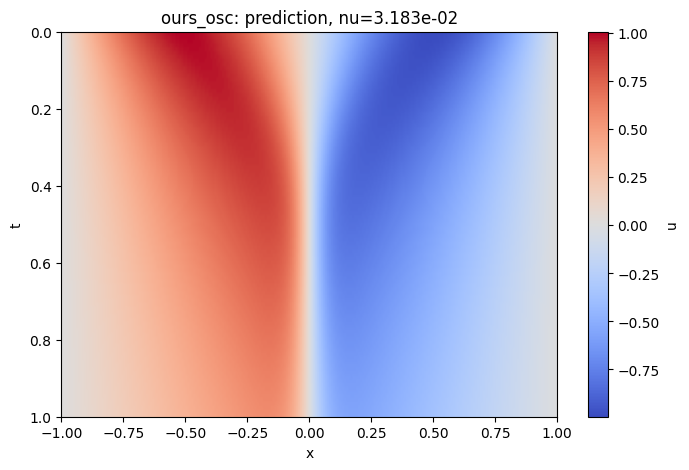

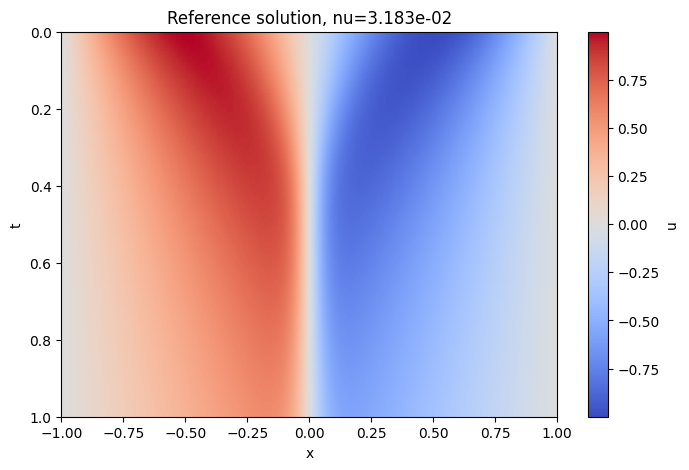

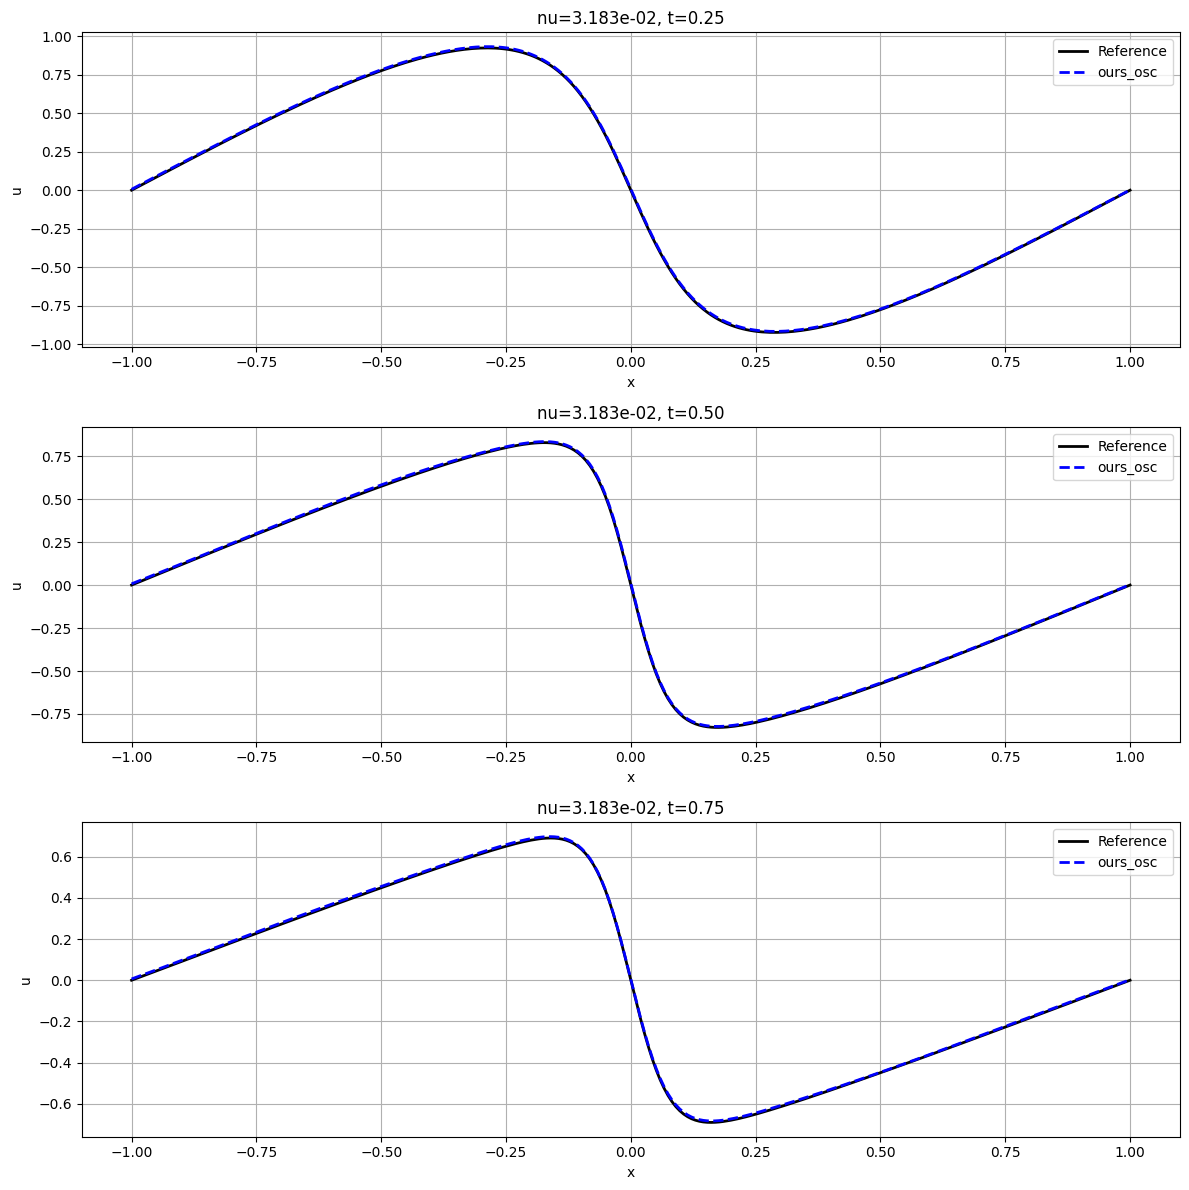

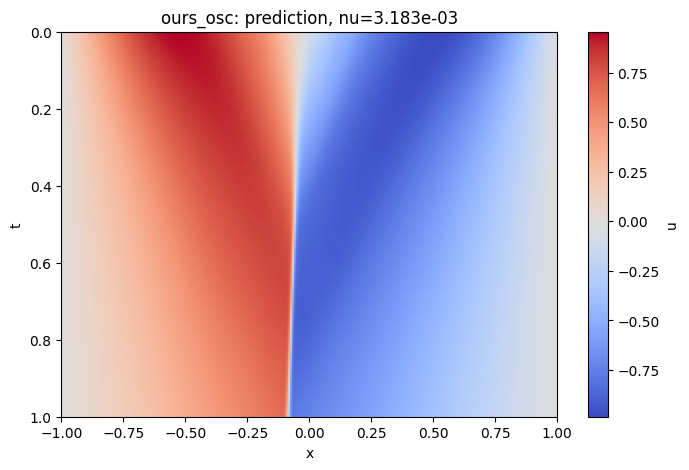

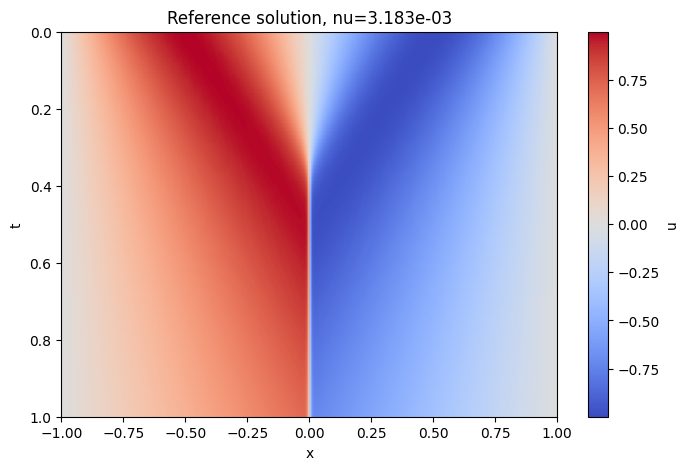

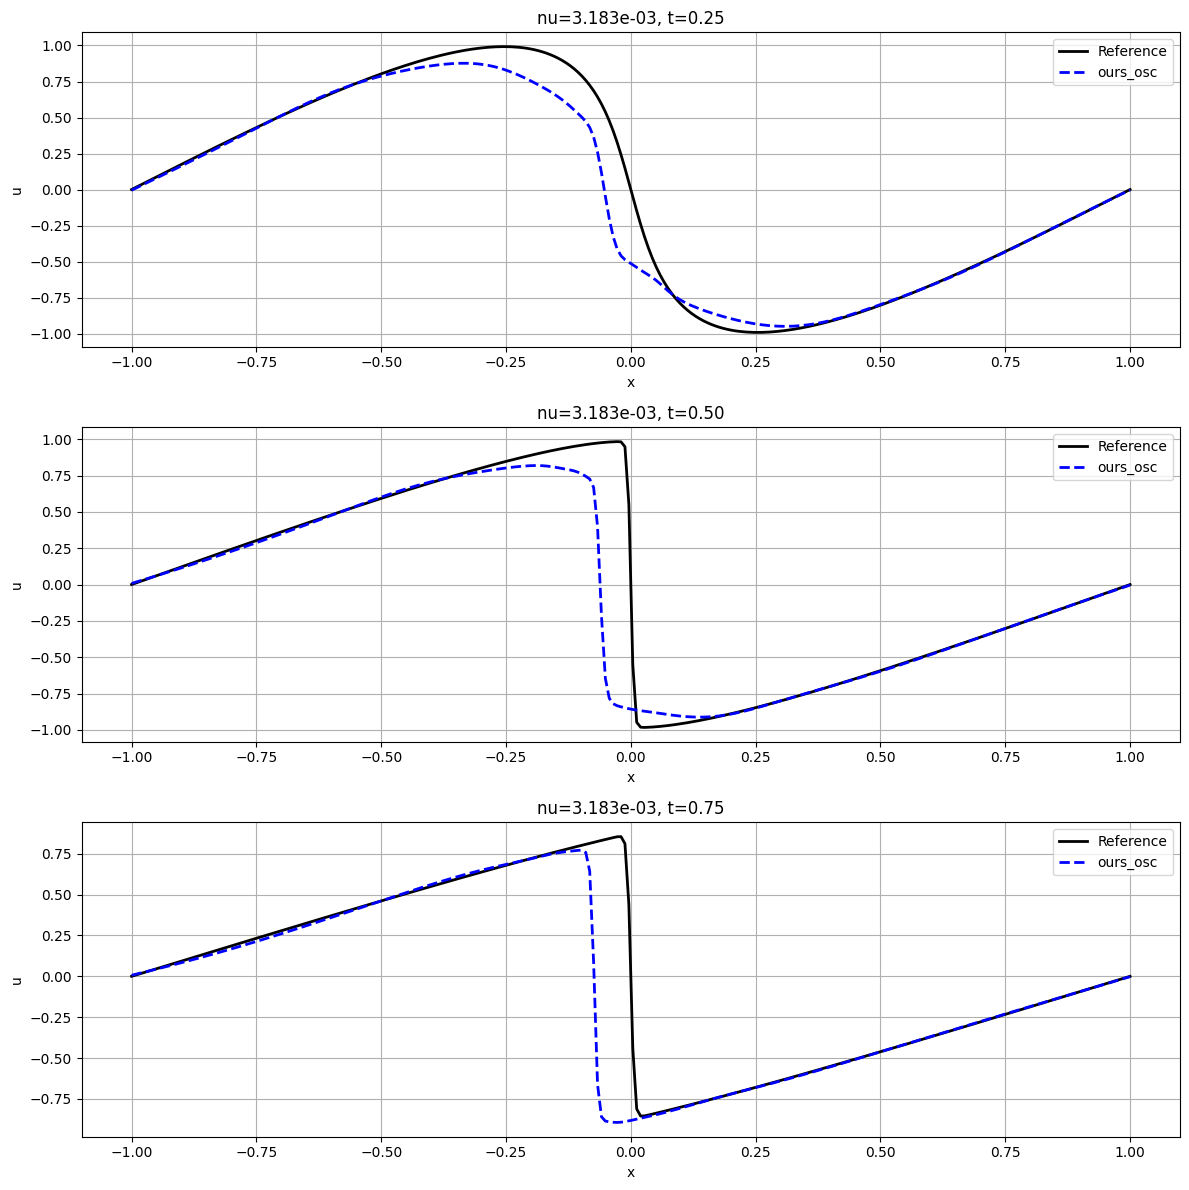

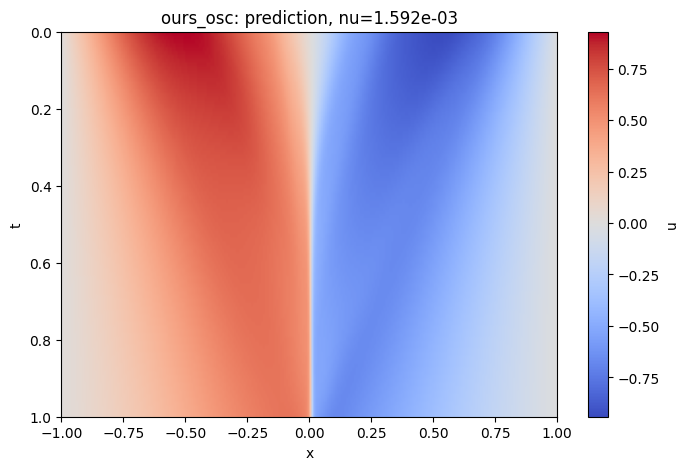

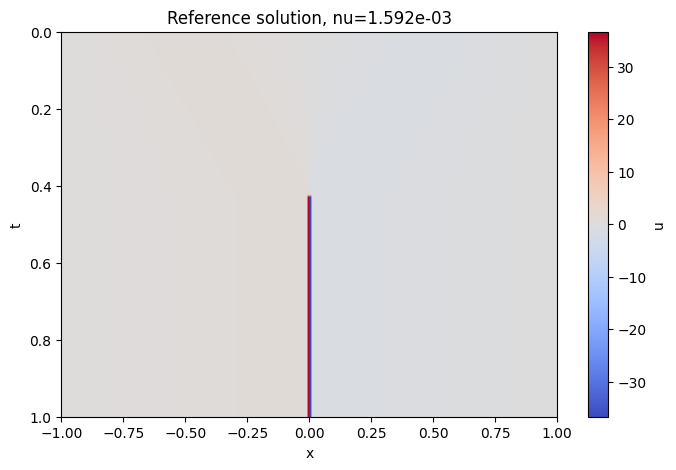

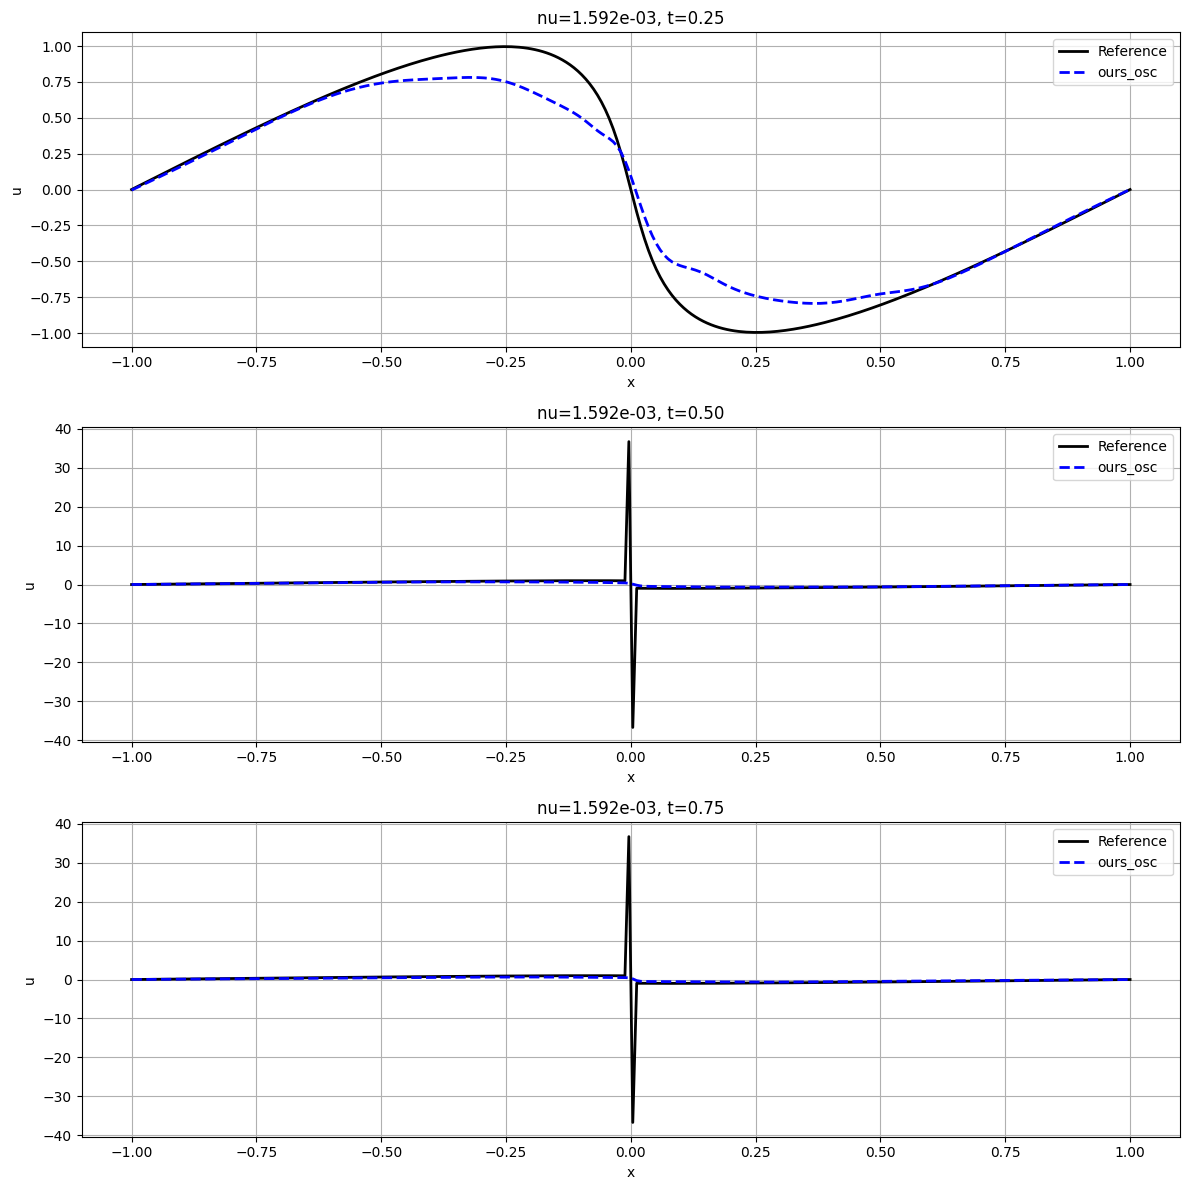

In [25]:
if __name__ == "__main__":
    # Вариант 1: один эксперимент
    # nu = 0.01 / np.pi
    # run_single_nu_experiment(nu)

    # Вариант 2: несколько значений вязкости
    results = run_multi_viscosity_experiment()
    plot_multi_viscosity_results(results, method_to_plot="ours_osc")


In [27]:
import pandas as pd
from scipy.integrate import solve_ivp

def run_multiseed_multinu_experiment( epochs=3000):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Starting Multi-Seed Multi-Nu Experiment on {device}")

    # Словарь с нужными нам значениями вязкости и их строковыми метками для таблицы
    nu_dict = {
        "$0.1/\\pi$": 0.1 / np.pi,
        "$0.01/\\pi$": 0.01 / np.pi,
        "$0.005/\\pi$": 0.005 / np.pi
    }

    # Сиды для воспроизводимости
    seeds = [17, 42, 123, 256, 777]

    # Конфигурации методов
    configs = {
        "Baseline": {"reg_type": "none", "lambda_reg": 0.0},
        "Grad": {"reg_type": "grad", "lambda_reg": 1e-4},
        "Hessian": {"reg_type": "hessian", "lambda_reg": 1e-6},
        "TV": {"reg_type": "tv", "lambda_reg": 1e-4},
        "Ours (Osc)": {"reg_type": "osc", "lambda_reg": 1e-3},
    }

    all_metrics = []

    for nu_label, nu in nu_dict.items():
        print("\n" + "="*70)
        print(f" EXPERIMENTS FOR nu = {nu_label} ({nu:.6e})")
        print("="*70)

        # 1. Готовим эталонное решение ОДИН раз для текущего nu
        print("Computing implicit reference solution...")
        x_ref, t_ref, U_ref = burgers_reference_solver(nu=nu, nx=512, nt=100)
        x_test = np.linspace(-1, 1, 256)
        t_test = np.linspace(0, 1, 101)
        U_ref_test = interpolate_reference_to_grid(x_ref, t_ref, U_ref, x_test, t_test)

        # 2. Перебираем сиды
        for seed in seeds:
            print(f"\n--- SEED: {seed} ---")

            # 3. Обучаем все методы
            for name, cfg in configs.items():
                print(f"Training {name} ...", end=" ")
                model, _ = train_burgers(
                    nu=nu,
                    reg_type=cfg["reg_type"],
                    lambda_reg=cfg["lambda_reg"],
                    epochs=epochs,
                    device=device,
                    verbose_every=epochs,  # Выводим лог только на последней эпохе
                    seed=seed
                )

                # Оценка
                U_pred = predict_on_grid(model, t_test, x_test, device=device)
                metrics = compute_metrics(U_pred, U_ref_test)
                metrics["pde"] = evaluate_pde_residual(model, nu, t_test, x_test, device=device)

                all_metrics.append({
                    "nu_label": nu_label,
                    "Method": name,
                    "Seed": seed,
                    "RelL2": metrics["rel_l2"],
                    "Linf": metrics["linf"],
                    "MSE": metrics["mse"],
                    "PDE": metrics["pde"]
                })
                print("Done!")

    # ==========================================
    # ОБРАБОТКА И ГЕНЕРАЦИЯ LATEX
    # ==========================================
    df = pd.DataFrame(all_metrics)
    df.to_csv("burgers_multinu_results.csv", index=False)
    print("\nRaw results saved to 'burgers_multinu_results.csv'.")

    # Аггрегация данных (среднее и std)
    agg_df = df.groupby(["nu_label", "Method"]).agg(["mean", "std"])

    print("\n\n" + "="*70)
    print("ГОТОВЫЙ КОД ДЛЯ LATEX ТАБЛИЦЫ")
    print("="*70 + "\n")

    latex_str = "\\begin{table}[h!]\n\\centering\n"
    latex_str += "\\caption{Сравнение точности и невязки уравнения для различных методов при разной вязкости (усреднение по 5 независимым запускам).}\n"
    latex_str += "\\vspace{0.2cm}\n"
    latex_str += "\\resizebox{\\textwidth}{!}{\n" # Масштабируем таблицу, чтобы влезла в страницу
    latex_str += "\\begin{tabular}{llcccc}\n\\hline\n"
    latex_str += "\\textbf{Вязкость $\\nu$} & \\textbf{Метод} & \\textbf{Rel. $L_2$} & \\textbf{$L_\\infty$} & \\textbf{MSE ($\\times 10^{-3}$)} & \\textbf{PDE Residual ($\\times 10^{-2}$)} \\\\\n\\hline\n"

    method_order = ["Baseline", "Grad", "Hessian", "TV", "Ours (Osc)"]

    for nu_label in nu_dict.keys():
        first_row_for_nu = True

        for method in method_order:
            row = agg_df.loc[(nu_label, method)]

            rel_l2_m, rel_l2_s = row[("RelL2", "mean")], row[("RelL2", "std")]
            linf_m, linf_s = row[("Linf", "mean")], row[("Linf", "std")]
            mse_m, mse_s = row[("MSE", "mean")] * 1000, row[("MSE", "std")] * 1000
            pde_m, pde_s = row[("PDE", "mean")] * 100, row[("PDE", "std")] * 100

            # Печатаем значение nu только в первой строке блока
            nu_col_text = nu_label if first_row_for_nu else ""
            first_row_for_nu = False

            # Оформляем строку
            latex_str += f"{nu_col_text} & {method} & ${rel_l2_m:.3f} \\pm {rel_l2_s:.3f}$ & ${linf_m:.3f} \\pm {linf_s:.3f}$ & ${mse_m:.2f} \\pm {mse_s:.2f}$ & ${pde_m:.2f} \\pm {pde_s:.2f}$ \\\\\n"

        latex_str += "\\hline\n" # Разделитель между блоками с разным nu

    latex_str += "\\end{tabular}\n}\n\\label{tab:multinu_results}\n\\end{table}"

    print(latex_str)
    return df

if __name__ == "__main__":
    # Запуск 3 сидов для 3 значений вязкости (всего 3 * 3 * 5 = 45 обучений нейросети)
    # На GPU это займет около 20-30 минут
    df = run_multiseed_multinu_experiment(epochs=3000)

Starting Multi-Seed Multi-Nu Experiment on cuda

 EXPERIMENTS FOR nu = $0.1/\pi$ (3.183099e-02)
Computing implicit reference solution...

--- SEED: 17 ---
Training Baseline ... [none] Epoch     0 | Total=5.3878e+00 | PDE=4.4084e-04 | IC=5.3800e-01 | BC=7.4512e-03 | REG=0.0000e+00
[none] Epoch  2999 | Total=9.7888e-04 | PDE=9.0044e-04 | IC=6.1674e-06 | BC=1.6765e-05 | REG=0.0000e+00
[none] Training finished in 29.04 sec
Done!
Training Grad ... [grad] Epoch     0 | Total=5.3878e+00 | PDE=4.4084e-04 | IC=5.3800e-01 | BC=7.4512e-03 | REG=2.8590e-03
[grad] Epoch  2999 | Total=1.5530e-03 | PDE=9.0679e-04 | IC=6.2233e-06 | BC=1.7272e-05 | REG=5.6667e+00
[grad] Training finished in 35.47 sec
Done!
Training Hessian ... [hessian] Epoch     0 | Total=5.3878e+00 | PDE=4.4084e-04 | IC=5.3800e-01 | BC=7.4512e-03 | REG=4.3475e-04
[hessian] Epoch  2999 | Total=1.5299e-03 | PDE=9.1751e-04 | IC=6.2741e-06 | BC=1.7293e-05 | REG=5.3232e+02
[hessian] Training finished in 40.89 sec
Done!
Training TV ... [tv

NameError: name 'n_seeds' is not defined

In [31]:

nu_dict = {
    "$0.1/\\pi$": 0.1 / np.pi,
    "$0.01/\\pi$": 0.01 / np.pi,
    "$0.005/\\pi$": 0.005 / np.pi
}


df=pd.read_csv('/content/burgers_multinu_results.csv')
 # Аггрегация данных (среднее и std)
agg_df = df.groupby(["nu_label", "Method"]).agg(["mean", "std"])

print("\n\n" + "="*70)
print("ГОТОВЫЙ КОД ДЛЯ LATEX ТАБЛИЦЫ")
print("="*70 + "\n")

latex_str = "\\begin{table}[h!]\n\\centering\n"
latex_str += "\\caption{Сравнение точности и невязки уравнения для различных методов при разной вязкости (усреднение по 5 независимым запускам).}\n"
latex_str += "\\vspace{0.2cm}\n"
latex_str += "\\resizebox{\\textwidth}{!}{\n" # Масштабируем таблицу, чтобы влезла в страницу
latex_str += "\\begin{tabular}{llcccc}\n\\hline\n"
latex_str += "\\textbf{Вязкость $\\nu$} & \\textbf{Метод} & \\textbf{Rel. $L_2$} & \\textbf{$L_\\infty$} & \\textbf{MSE ($\\times 10^{-3}$)} & \\textbf{PDE Residual ($\\times 10^{-2}$)} \\\\\n\\hline\n"

method_order = ["Baseline", "Grad", "Hessian", "TV", "Ours (Osc)"]

for nu_label in nu_dict.keys():
    first_row_for_nu = True

    for method in method_order:
        row = agg_df.loc[(nu_label, method)]

        rel_l2_m, rel_l2_s = row[("RelL2", "mean")], row[("RelL2", "std")]
        linf_m, linf_s = row[("Linf", "mean")], row[("Linf", "std")]
        mse_m, mse_s = row[("MSE", "mean")] * 1000, row[("MSE", "std")] * 1000
        pde_m, pde_s = row[("PDE", "mean")] * 100, row[("PDE", "std")] * 100

        # Печатаем значение nu только в первой строке блока
        nu_col_text = nu_label if first_row_for_nu else ""
        first_row_for_nu = False

        # Оформляем строку
        latex_str += f"{nu_col_text} & {method} & ${rel_l2_m:.3f} \\pm {rel_l2_s:.3f}$ & ${linf_m:.3f} \\pm {linf_s:.3f}$ & ${mse_m:.2f} \\pm {mse_s:.2f}$ & ${pde_m:.2f} \\pm {pde_s:.2f}$ \\\\\n"

    latex_str += "\\hline\n" # Разделитель между блоками с разным nu

latex_str += "\\end{tabular}\n}\n\\label{tab:multinu_results}\n\\end{table}"

print(latex_str)
return df



ГОТОВЫЙ КОД ДЛЯ LATEX ТАБЛИЦЫ

\begin{table}[h!]
\centering
\caption{Сравнение точности и невязки уравнения для различных методов при разной вязкости (усреднение по 5 независимым запускам).}
\vspace{0.2cm}
\resizebox{\textwidth}{!}{
\begin{tabular}{llcccc}
\hline
\textbf{Вязкость $\nu$} & \textbf{Метод} & \textbf{Rel. $L_2$} & \textbf{$L_\infty$} & \textbf{MSE ($\times 10^{-3}$)} & \textbf{PDE Residual ($\times 10^{-2}$)} \\
\hline
$0.1/\pi$ & Baseline & $0.004 \pm 0.002$ & $0.010 \pm 0.005$ & $0.01 \pm 0.00$ & $0.06 \pm 0.04$ \\
 & Grad & $0.006 \pm 0.003$ & $0.012 \pm 0.005$ & $0.01 \pm 0.01$ & $0.07 \pm 0.04$ \\
 & Hessian & $0.005 \pm 0.002$ & $0.011 \pm 0.005$ & $0.01 \pm 0.01$ & $0.07 \pm 0.04$ \\
 & TV & $0.004 \pm 0.002$ & $0.010 \pm 0.005$ & $0.01 \pm 0.00$ & $0.06 \pm 0.04$ \\
 & Ours (Osc) & $0.006 \pm 0.003$ & $0.012 \pm 0.005$ & $0.01 \pm 0.01$ & $0.07 \pm 0.04$ \\
\hline
$0.01/\pi$ & Baseline & $0.186 \pm 0.077$ & $1.207 \pm 0.519$ & $14.73 \pm 9.65$ & $6.85 \pm 1.25$ \

SyntaxError: 'return' outside function (2824177276.py, line 48)